In [2]:
import numpy as np
import struct

def load_mnist(images_path, labels_path):
    with open(labels_path, 'rb') as f:
        struct.unpack('>II', f.read(8))
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    
    with open(images_path, 'rb') as f:
        struct.unpack('>IIII', f.read(16))
        images = np.frombuffer(f.read(), dtype=np.uint8)
        images = images.reshape(-1, 784)
    
    return images, labels

X_train, y_train = load_mnist('train-images.idx3-ubyte', 'train-labels.idx1-ubyte')
X_test, y_test = load_mnist('t10k-images.idx3-ubyte', 't10k-labels.idx1-ubyte')

# Normalize to 0-1
X_train = X_train / 255.0
X_test = X_test / 255.0

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(60000, 784) (60000,)
(10000, 784) (10000,)


In [7]:
def softmax(z):
    ez = np.exp(z - np.max(z, axis=0, keepdims=True))  # stability trick
    return ez / np.sum(ez, axis=0, keepdims=True)
def relu(T):
    return np.maximum(0,T)

In [4]:
def one_hot(y, classes=10):
    m = y.shape[0]
    oh = np.zeros((classes, m))
    oh[y, np.arange(m)] = 1
    return oh

y_train_oh = one_hot(y_train)
print(y_train_oh.shape)

(10, 60000)


In [5]:
np.random.seed(42)
W1 = np.random.randn(128, 784) * 0.01
b1 = np.zeros((128, 1))
W2 = np.random.randn(10, 128) * 0.01
b2 = np.zeros((10, 1))

lr = 0.1

In [8]:
def forward(X):
    Z1 = W1 @ X.T + b1    # (128, 60000)
    A1 = relu(Z1)           # (128, 60000)
    Z2 = W2 @ A1 + b2      # (10, 60000)
    A2 = softmax(Z2)        # (10, 60000)
    return Z1, A1, Z2, A2

Z1, A1, Z2, A2 = forward(X_train)
print(A2.shape)
print(A2[:, 0])  # probabilities for first image

(10, 60000)
[0.10082781 0.09914206 0.1006992  0.09981838 0.09840807 0.10026078
 0.10014593 0.10025836 0.09977759 0.10066181]


In [9]:
def compute_loss(A2, y_oh):
    m = y_oh.shape[1]
    L = -np.sum(y_oh * np.log(A2 + 1e-8)) / m
    return L

loss = compute_loss(A2, y_train_oh)
print(loss)

2.302835447984187


In [10]:
def backward(X, y_oh, Z1, A1, Z2, A2):
    m = X.shape[0]
    
    dZ2 = A2 - y_oh                           # (10, 60000)
    dW2 = (dZ2 @ A1.T) / m                   # (10, 128)
    db2 = np.sum(dZ2, axis=1, keepdims=True) / m  # (10, 1)
    
    dA1 = W2.T @ dZ2                          # (128, 60000)
    dZ1 = dA1 * (Z1 > 0)                     # (128, 60000)
    dW1 = (dZ1 @ X) / m                      # (128, 784)
    db1 = np.sum(dZ1, axis=1, keepdims=True) / m  # (128, 1)
    
    return dW1, db1, dW2, db2

In [11]:
dW1, db1, dW2, db2 = backward(X_train, y_train_oh, Z1, A1, Z2, A2)
print(dW2.shape)

(10, 128)


In [12]:
def update(dW1, db1, dW2, db2):
    global W1, b1, W2, b2
    W1 = W1 - lr * dW1
    b1 = b1 - lr * db1
    W2 = W2 - lr * dW2
    b2 = b2 - lr * db2

def accuracy(A2, y):
    predictions = np.argmax(A2, axis=0)  # pick highest probability class
    return np.mean(predictions == y) * 100

# Training loop
for epoch in range(500):
    Z1, A1, Z2, A2 = forward(X_train)
    loss = compute_loss(A2, y_train_oh)
    dW1, db1, dW2, db2 = backward(X_train, y_train_oh, Z1, A1, Z2, A2)
    update(dW1, db1, dW2, db2)
    
    if epoch % 50 == 0:
        acc = accuracy(A2, y_train)
        print(f"Epoch {epoch} | Loss: {loss:.4f} | Accuracy: {acc:.2f}%")

Epoch 0 | Loss: 2.3028 | Accuracy: 7.70%
Epoch 50 | Loss: 1.9781 | Accuracy: 64.39%
Epoch 100 | Loss: 0.9377 | Accuracy: 78.60%
Epoch 150 | Loss: 0.6207 | Accuracy: 84.66%
Epoch 200 | Loss: 0.5015 | Accuracy: 87.07%
Epoch 250 | Loss: 0.4408 | Accuracy: 88.23%
Epoch 300 | Loss: 0.4043 | Accuracy: 88.98%
Epoch 350 | Loss: 0.3799 | Accuracy: 89.50%
Epoch 400 | Loss: 0.3620 | Accuracy: 89.91%
Epoch 450 | Loss: 0.3481 | Accuracy: 90.27%


In [13]:
Z1, A1, Z2, A2 = forward(X_test)
test_acc = accuracy(A2, y_test)
print(f"Test Accuracy: {test_acc:.2f}%")

Test Accuracy: 90.78%


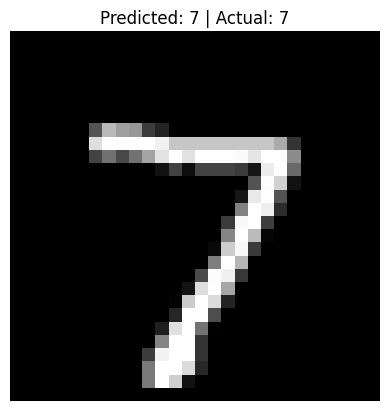

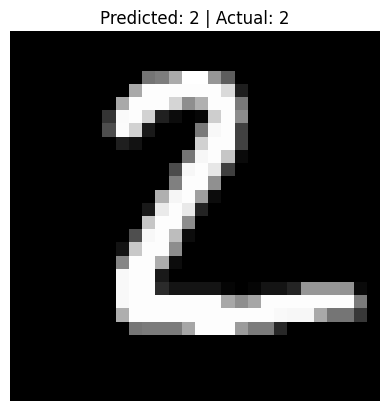

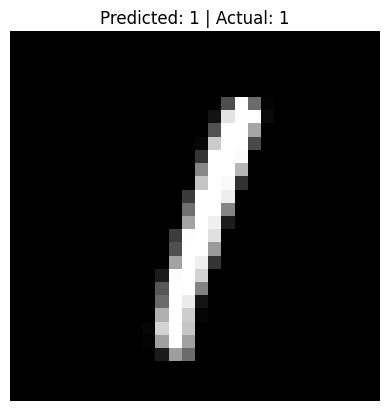

In [14]:
import matplotlib.pyplot as plt

def predict(index):
    img = X_test[index].reshape(1, 784)
    _, _, _, A2 = forward(img)
    pred = np.argmax(A2)
    true = y_test[index]
    
    plt.imshow(X_test[index].reshape(28, 28), cmap='gray')
    plt.title(f"Predicted: {pred} | Actual: {true}")
    plt.axis('off')
    plt.show()

predict(0)
predict(1)
predict(5)

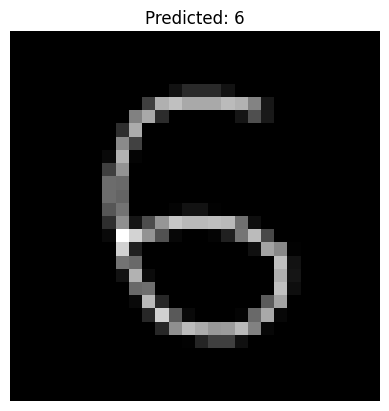

Predicted digit: 6


In [ ]:
from PIL import Image

def predict_custom(path):
    img = Image.open(path).convert('L')        # convert to grayscale
    img = img.resize((28, 28))                  # resize to 28x28
    img = np.array(img)                         # to numpy array
    img = 255 - img                             # invert (MNIST is white on black)
    img = img / 255.0                           # normalize
    img = img.reshape(1, 784)                   # flatten
    
    _, _, _, A2 = forward(img)
    pred = np.argmax(A2)
    
    plt.imshow(img.reshape(28, 28), cmap='gray')
    plt.title(f"Predicted: {pred}")
    plt.axis('off')
    plt.show()
    
    print(f"Predicted digit: {pred}")

predict_custom('image.png')